# Load and verify the baseline model

Demonstrates loading a saved baseline checkpoint and verifying that it produces the expected predictions, without retraining.

In [1]:
import sys
from pathlib import Path

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import tempfile

import numpy as np
import keras
import matplotlib.pyplot as plt

from src.data.freihand import (
    FreiHand,
    SPLIT_SEED,
    SPLIT_VALIDATION_FRACTION,
)

## Locate the latest training run

In [2]:
runs = sorted(p for p in (project_root / 'models').iterdir() if p.is_dir())
run_dir = runs[-1]
checkpoint_path = run_dir / 'best.keras'
config_path = project_root / 'logs' / run_dir.name / 'config.json'

config = json.loads(config_path.read_text())
print(f'Run:        {run_dir.name}')
print(f'Checkpoint: {checkpoint_path}')
print(f'Config:     {json.dumps(config, indent=2)}')

Run:        baseline
Checkpoint: /Users/victor/Projects/code/hand-pose-estimation/models/baseline/best.keras
Config:     {
  "run_name": "baseline",
  "epochs": 30,
  "batch_size": 32,
  "learning_rate": 0.001,
  "validation_fraction": 0.1,
  "seed": 42,
  "n_train": 29304,
  "n_val": 3256,
  "input_shape": [
    224,
    224,
    3
  ],
  "loss": "mse",
  "metrics": [
    "mae"
  ],
  "optimizer": "adam"
}


## Training curves

Replay the training history from `logs/<run>/history.json` and overlay train vs. validation for each metric. No retraining needed.

Saved figure: reports/figures/baseline_training_curves.png


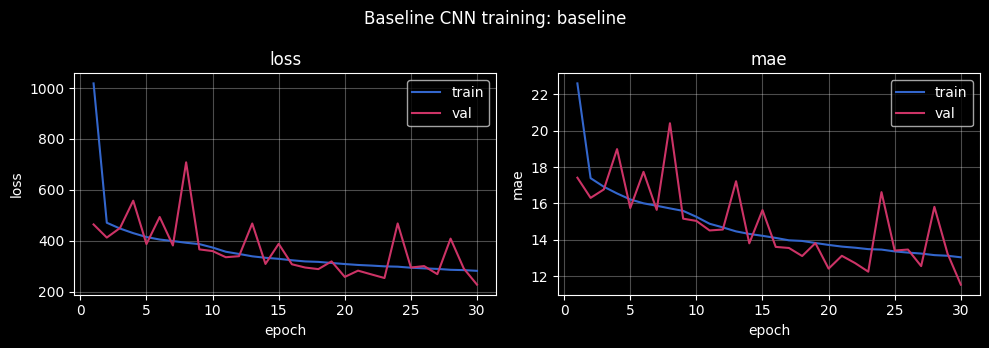

In [3]:
from src.evaluation.training_curves import load_history, plot_training_curves
from src.evaluation.overlays import save_figure

history = load_history(run_dir.name)
fig = plot_training_curves(history, suptitle=f'Baseline CNN training: {run_dir.name}')
saved_path = save_figure(fig, 'baseline_training_curves')
print(f'Saved figure: {saved_path.relative_to(project_root)}')
plt.show()

## Load the checkpoint

`keras.models.load_model` reconstructs the model architecture, weights, optimizer, and loss from the `.keras` file. No retraining required.

In [4]:
model = keras.models.load_model(checkpoint_path)
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │        10,794 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,992 (1.58 MB)

 Trainable params: 137,514 (537.16 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 275,030 (1.05 MB)

## Round-trip verification

Save the loaded model to a temporary path, reload it, and confirm the forward pass produces bit-exact predictions on a fixed input.

In [5]:
dummy = np.random.default_rng(0).random((4, 224, 224, 3), dtype=np.float32)
expected = model.predict(dummy, verbose=0)

with tempfile.TemporaryDirectory() as tmp:
    roundtrip_path = Path(tmp) / 'roundtrip.keras'
    model.save(roundtrip_path)
    reloaded = keras.models.load_model(roundtrip_path)
    actual = reloaded.predict(dummy, verbose=0)

assert np.array_equal(expected, actual), 'Round-trip predictions do not match'
print('Round-trip OK \u2014 reloaded model produces identical predictions.')

I0000 00:00:1777211608.211565 11888962 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Round-trip OK — reloaded model produces identical predictions.


## Visual sanity check on validation samples

Predict on a handful of held-out validation samples and overlay predicted keypoints (red) against ground truth (green).

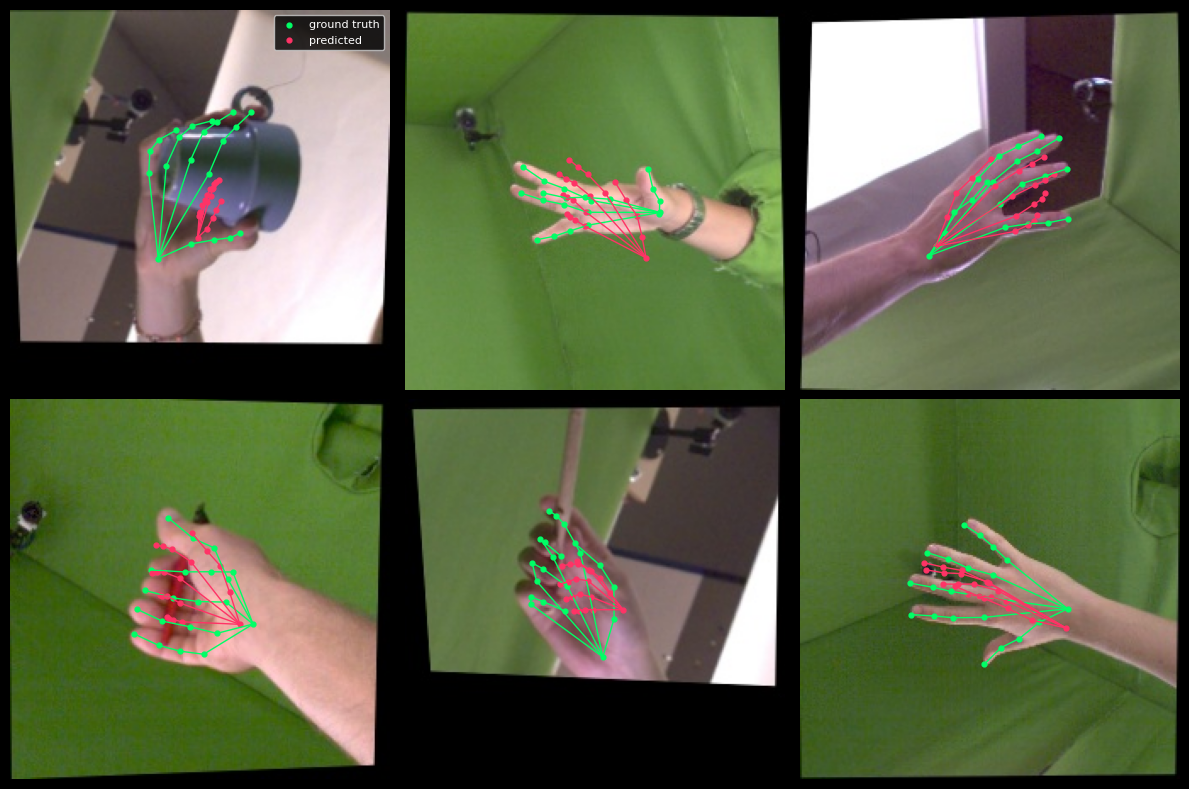

In [6]:
from src.evaluation.overlays import prediction_grid

dataset = FreiHand()
_, val_idx = dataset.train_validation_split(
    validation_fraction=SPLIT_VALIDATION_FRACTION,
    seed=SPLIT_SEED,
)
sample_ids = val_idx[:6]
images, ground_truth = dataset.load_batch(
    sample_ids,
    image_size=(224, 224),
    flatten_keypoints=False,
)
predictions = model.predict(images, verbose=0).reshape(-1, 21, 2)

prediction_grid(images, ground_truth, predictions, ncols=3)
plt.show()

## Metric on the full validation set

Run the trained model over every validation sample and report the Mean Per-Keypoint Error (MPKE) in pixels.

In [7]:
from src.evaluation.metrics import evaluate_model

val_ds = dataset.tf_dataset(
    indices=val_idx,
    batch_size=64,
    image_size=(224, 224),
    flatten_keypoints=True,
)
metrics = evaluate_model(model, val_ds)
print(metrics)

{'mpke_px': 18.099241256713867, 'median_sample_mpke_px': 17.22201156616211, 'p75_sample_mpke_px': 21.537906646728516, 'p90_sample_mpke_px': 26.320396423339844, 'p95_sample_mpke_px': 30.056838989257812, 'max_sample_mpke_px': 75.98968505859375, 'n_samples': 3256}


## Representative samples gallery

Pick the best, median, p90, and worst validation samples by per-sample MPKE and overlay predictions against ground truth. Save the figure to `reports/figures/`.

Saved figure: reports/figures/baseline_representative_predictions.png


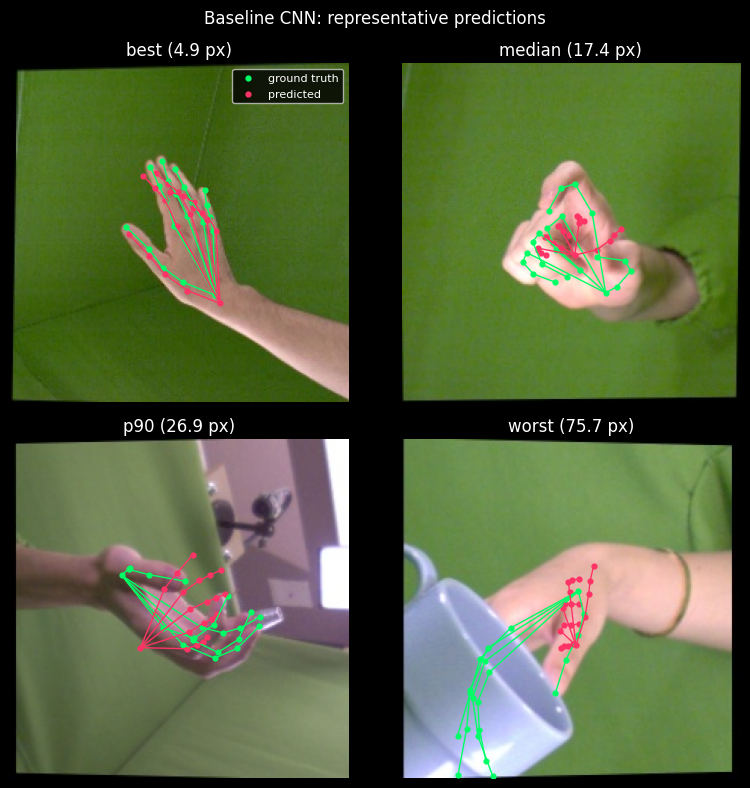

In [8]:
from src.evaluation.metrics import sample_mpke
from src.evaluation.overlays import prediction_grid, save_figure

metrics_with_idx = evaluate_model(model, val_ds, include_representative_indices=True)
indices = metrics_with_idx['representative_indices']

labels = ['best', 'median', 'p90', 'worst']
sample_ids = np.array([val_idx[indices[l]] for l in labels])
images, gt = dataset.load_batch(sample_ids, image_size=(224, 224), flatten_keypoints=False)
preds = model.predict(images, verbose=0).reshape(-1, 21, 2)

errors = sample_mpke(preds, gt)
titles = [f'{label} ({err:.1f} px)' for label, err in zip(labels, errors)]

fig = prediction_grid(images, gt, preds, titles=titles, ncols=2,
                      suptitle='Baseline CNN: representative predictions')
saved_path = save_figure(fig, 'baseline_representative_predictions')
print(f'Saved figure: {saved_path.relative_to(project_root)}')
plt.show()